<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D1%85_%D1%80%D1%8F%D0%B4%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%7C_%D0%94%D0%97_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Обучите нейронную сеть для прогноза стоимости акций на данных, которые необходимо подготовить по инструкции, прописанной ниже.

Используйте базу акций Лукойла.

1. Сделайте несколько усовершенствований в предсказании временного ряда.
Добавьте к исходному сигналу расширенные данные:

* попарные разности каналов
* модули попарных разностей каналов
* попарные произведения каналов
* обратное значение каналов x_new = 1/(x + 1e-3)
* первые производные каналов (x[n] - x[n-1])
* вторые производные каналов (x[n] - 2*x[n-1] + x[n-2])

2. Примените абсолютно новый подход. Сделайте бОльший “просмотр сети в прошлое” (можно использовать исходный датасет без расширения (5 базовых столбцов)), при формировании входного сигнала используйте:

* 100 точек с шагом назад по 1,

* 100 точек с шагом назад по 10 (или сами точки, или среднее по отрезку в 10 точек).
* Объедините эти точки

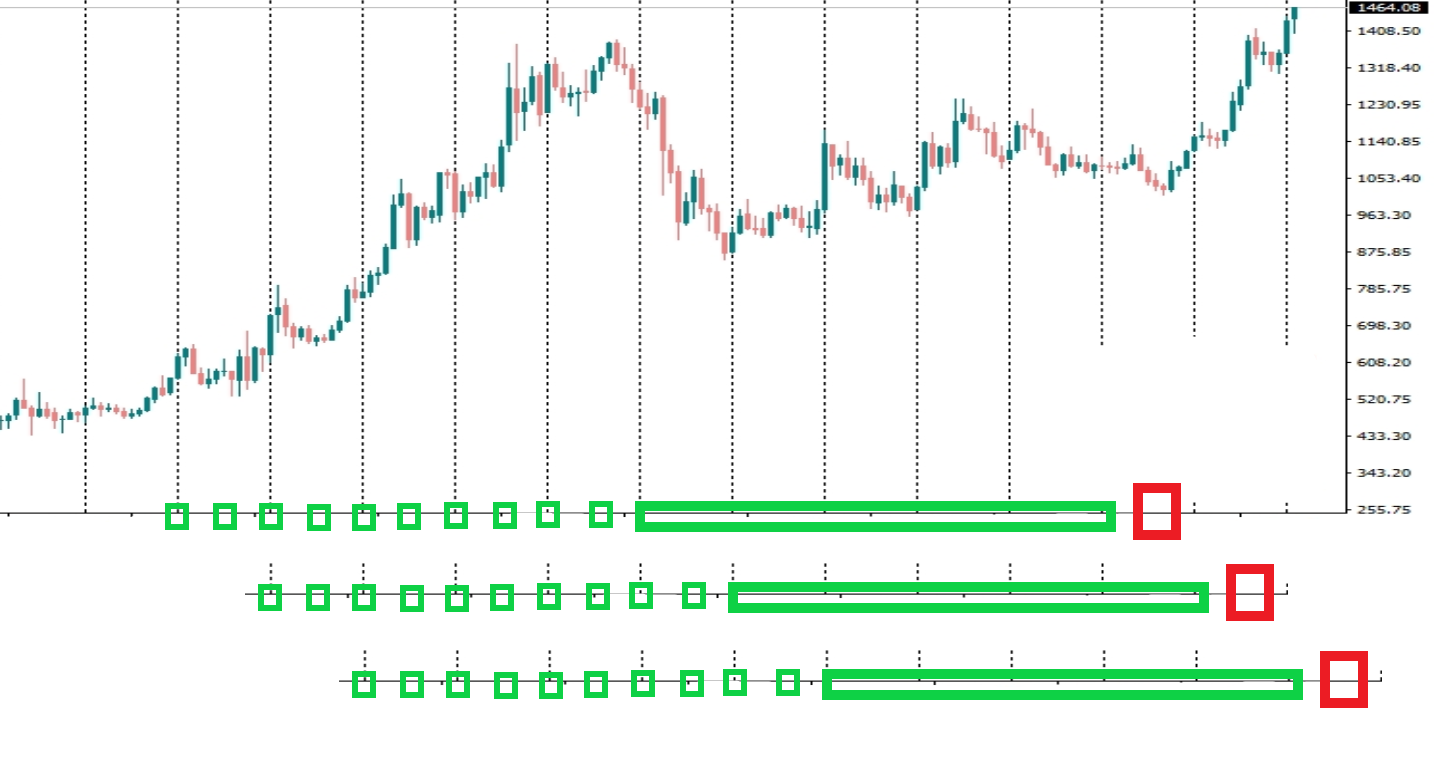

## Подготовка

In [1]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Классы-конструкторы моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, LSTM, MaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировщики
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Коллбэк
from tensorflow.keras.callbacks import LearningRateScheduler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

# Отрисовка графики в ячейке colab
%matplotlib inline

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Назначение размера и стиля графиков по умолчанию

from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

In [4]:
# Загрузка датасетов из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/16_17.csv', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/18_19.csv', None, quiet=True)

'18_19.csv'

In [3]:
# Чтение данных в таблицы с удалением ненужных столбцов

data16_17 = pd.read_csv('16_17.csv', sep=';').drop(columns=['DATE', 'TIME'])
data18_19 = pd.read_csv('18_19.csv', sep=';').drop(columns=['DATE', 'TIME'])

In [4]:
# Просмотр размерностей получившихся таблиц

print(data16_17.shape)
print(data18_19.shape)

(263925, 5)
(217947, 5)


In [5]:
# Создание общего набора данных из двух датасетов

data = pd.concat([data16_17,data18_19])   # Объединение датасетов
data = data.reset_index(drop = True)      # Обнуление индексов

# Проверка формы данных
print(data.shape)

(481872, 5)


In [6]:
# Получение названий столбцов

col = data.columns
print(col)

Index(['OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME'], dtype='object')


In [7]:
# Задание циклов для столбцов таким образом, чтобы происходил перебор всех возможных пар:
# Перебор индексов массива с именами столбцов 'OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME',
# получая пары 'OPEN' и 'MAX', 'OPEN' и 'MIN', 'OPEN' и 'CLOSE' ..., 'MAX' и 'MIN', 'MAX' и 'CLOSE' и т.д

for i in range(col.shape[0]): # Для всех пар
    for j in range(i + 1 , col.shape[0]): # Расчет
        data[col[i] + '-' + col[j]] = data[col[i]] - data[col[j]] # Разности
        data['|' + col[i] + '-' + col[j] + '|'] = abs(data[col[i]] - data[col[j]]) # Модулей разностей
        data[col[i] + '*' + col[j]] = data[col[i]] * data[col[j]] # Произведения

# Для каждого столбца 'OPEN', 'MAX', 'MIN', 'CLOSE', 'VOLUME' расчет:
for i in col:
    # Обратные значения. 1e-3 в формуле нужно, чтобы случайно не разделить на 0
    data['Обратный ' + i] = 1 / (data[i] + 1e-3)
    # Создание пустого столбца
    data['Производная от ' + i] = np.nan
    # При помощи срезов расчет первых производных, .reset_index(drop=True) нужен для корректных расчетов
    data['Производная от ' + i][1:] = data[i][1:].reset_index(drop=True) - data[i][:-1].reset_index(drop=True)
    # Создание пустого столбца
    data['Вторая производная от ' + i] = np.nan
    # При помощи срезов расчет вторых производных
    data['Вторая производная от ' + i][2:] = data[i][2:].reset_index(drop=True) - 2 * data[i][1:-1].reset_index(drop=True) + data[i][:-2].reset_index(drop=True)


In [8]:
# Просмотр результатов
data

,OPEN,MAX,MIN,CLOSE,VOLUME,OPEN-MAX,|OPEN-MAX|,OPEN*MAX,OPEN-MIN,|OPEN-MIN|,...,Вторая производная от MAX,Обратный MIN,Производная от MIN,Вторая производная от MIN,Обратный CLOSE,Производная от CLOSE,Вторая производная от CLOSE,Обратный VOLUME,Производная от VOLUME,Вторая производная от VOLUME
0,2351.0,2355.8,2350.0,2350.0,2547,-4.8,4.8,5538485.80,1.0,1.0,...,NaN,0.000426,NaN,NaN,0.000426,NaN,NaN,0.000393,NaN,NaN
1,2352.9,2355.7,2350.0,2355.7,195,-2.8,2.8,5542726.53,2.9,2.9,...,NaN,0.000426,0.0,NaN,0.000425,5.7,NaN,0.005128,-2352.0,NaN
2,2355.6,2356.0,2351.4,2354.1,257,-0.4,0.4,5549793.60,4.2,4.2,...,0.4,0.000425,1.4,1.4,0.000425,-1.6,-7.3,0.003891,62.0,2414.0
3,2354.5,2355.0,2351.2,2353.7,763,-0.5,0.5,5544847.50,3.3,3.3,...,-1.3,0.000425,-0.2,-1.6,0.000425,-0.4,1.2,0.001311,506.0,444.0
4,2353.1,2353.9,2353.1,2353.6,231,-0.8,0.8,5538962.09,0.0,0.0,...,-0.1,0.000425,1.9,2.1,0.000425,-0.1,0.3,0.004329,-532.0,-1038.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481867,5183.5,5183.5,5183.5,5183.5,31523,0.0,0.0,26868672.25,0.0,0.0,...,11.5,0.000193,16.0,18.0,0.000193,11.5,10.0,0.000032,29174.0,29480.0
481868,5183.5,5183.5,5183.5,5183.5,5090,0.0,0.0,26868672.25,0.0,0.0,...,-11.5,0.000193,0.0,-16.0,0.000193,0.0,-11.5,0.000196,-26433.0,-55607.0
481869,5183.5,5183.5,5183.5,5183.5,230,0.0,0.0,26868672.25,0.0,0.0,...,0.0,0.000193,0.0,0.0,0.000193,0.0,0.0,0.004348,-4860.0,21573.0
481870,5183.5,5183.5,5183.5,5183.5,5,0.0,0.0,26868672.25,0.0,0.0,...,0.0,0.000193,0.0,0.0,0.000193,0.0,0.0,0.199960,-225.0,4635.0


In [9]:
# Просмотр результатов
# Удаление строк с неполными данными
data.dropna(inplace=True)
data

,OPEN,MAX,MIN,CLOSE,VOLUME,OPEN-MAX,|OPEN-MAX|,OPEN*MAX,OPEN-MIN,|OPEN-MIN|,...,Вторая производная от MAX,Обратный MIN,Производная от MIN,Вторая производная от MIN,Обратный CLOSE,Производная от CLOSE,Вторая производная от CLOSE,Обратный VOLUME,Производная от VOLUME,Вторая производная от VOLUME
2,2355.6,2356.0,2351.4,2354.1,257,-0.4,0.4,5549793.60,4.2,4.2,...,0.4,0.000425,1.4,1.4,0.000425,-1.6,-7.3,0.003891,62.0,2414.0
3,2354.5,2355.0,2351.2,2353.7,763,-0.5,0.5,5544847.50,3.3,3.3,...,-1.3,0.000425,-0.2,-1.6,0.000425,-0.4,1.2,0.001311,506.0,444.0
4,2353.1,2353.9,2353.1,2353.6,231,-0.8,0.8,5538962.09,0.0,0.0,...,-0.1,0.000425,1.9,2.1,0.000425,-0.1,0.3,0.004329,-532.0,-1038.0
5,2351.8,2351.8,2350.0,2350.0,934,0.0,0.0,5530963.24,1.8,1.8,...,-1.0,0.000426,-3.1,-5.0,0.000426,-3.6,-3.5,0.001071,703.0,1235.0
6,2350.0,2350.0,2346.9,2347.9,948,0.0,0.0,5522500.00,3.1,3.1,...,0.3,0.000426,-3.1,0.0,0.000426,-2.1,1.5,0.001055,14.0,-689.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481867,5183.5,5183.5,5183.5,5183.5,31523,0.0,0.0,26868672.25,0.0,0.0,...,11.5,0.000193,16.0,18.0,0.000193,11.5,10.0,0.000032,29174.0,29480.0
481868,5183.5,5183.5,5183.5,5183.5,5090,0.0,0.0,26868672.25,0.0,0.0,...,-11.5,0.000193,0.0,-16.0,0.000193,0.0,-11.5,0.000196,-26433.0,-55607.0
481869,5183.5,5183.5,5183.5,5183.5,230,0.0,0.0,26868672.25,0.0,0.0,...,0.0,0.000193,0.0,0.0,0.000193,0.0,0.0,0.004348,-4860.0,21573.0
481870,5183.5,5183.5,5183.5,5183.5,5,0.0,0.0,26868672.25,0.0,0.0,...,0.0,0.000193,0.0,0.0,0.000193,0.0,0.0,0.199960,-225.0,4635.0


In [10]:
# Задание текстовых меток каналов данных (столбцов)

CHANNEL_NAMES = list(col)
CHANNEL_INDEX = {name: chan for chan, name in enumerate(CHANNEL_NAMES)}
#print(CHANNEL_NAMES, CHANNEL_INDEX)

# Использование всех столбцов, кроме первых двух
data = np.array(data.iloc[2:])

# Перевод в numpy
data = np.array(data)

# Переменная, для использования одной и той же архитектуры под разные матрицы
columnsamount = data.shape[1]


In [11]:
# Задание гиперпараметров

CHANNEL_X = CHANNEL_NAMES                 # Отбор каналов входных данных
CHANNEL_Y = ['CLOSE']                     # Отбор каналов данных для предсказания
SEQ_LEN = 200                             # Длина прошедших данных для анализа
BATCH_SIZE = 10                           # Объем батча для генератора
TEST_LEN = 30000                          # Объем тестовой выборки
TRAIN_LEN = data.shape[0] - TEST_LEN      # Объем обучающей выборки

In [12]:
# Формирование списков индексов каналов данных для входных и выходных выборок
chn_x = [CHANNEL_INDEX[c] for c in CHANNEL_X]
chn_y = [CHANNEL_INDEX[c] for c in CHANNEL_Y]

# Проверка результата
print(chn_x, chn_y)

# Разделение данных на тренировочный и тестовый наборы
# 2*SEQ_LEN - для разрыва между тренировочными и тестовыми данными
# варьируемый параметр, страховка от пересечения
data_train, data_test = data[:TRAIN_LEN], data[TRAIN_LEN + 2*SEQ_LEN:]

# Отбор входных данных
x_data_train, x_data_test = data_train[:, chn_x], data_test[:, chn_x]

# Масштабирование данных
x_scaler = MinMaxScaler()
x_scaler.fit(x_data_train)
x_data_train = x_scaler.transform(x_data_train)
x_data_test = x_scaler.transform(x_data_test)

# Отбор выходных данных
y_data_train, y_data_test = data_train[:, chn_y], data_test[:, chn_y]

# Масштабирование данных
y_scaler = MinMaxScaler()
y_scaler.fit(y_data_train)
y_data_train = y_scaler.transform(y_data_train)
y_data_test = y_scaler.transform(y_data_test)

# Проверка формы данных
print(f'Train data: {x_data_train.shape}, {y_data_train.shape}')
print(f'Test  data: {x_data_test.shape}, {y_data_test.shape}')


[0, 1, 2, 3, 4] [3]
Train data: (451868, 5), (451868, 1)
Test  data: (29600, 5), (29600, 1)


In [13]:
# Функция разделения набора данных на выборки для обучения нейросети
# x_data - набор входных данных
# y_data - набор выходных данных
# seq_len - длина серии (подпоследовательности) входных данных для анализа
# predict_lag - количество шагов в будущее для предсказания
def split_sequence(x_data, y_data, seq_len, predict_lag):
    # Определение максимального индекса начала подпоследовательности
    x_len = x_data.shape[0] - seq_len - (predict_lag - 1)
    # Формирование подпоследовательностей входных данных
    x = [x_data[i:i + seq_len] for i in range(x_len)]
    # Формирование меток выходных данных,
    # отстоящих на predict_lag шагов после конца подпоследовательности
    y = [y_data[i + seq_len + predict_lag - 1] for i in range(x_len)]
    # Возврат результатов в виде массивов numpy
    return np.array(x), np.array(y)

In [14]:
PREDICT_LAG=10
x_train, y_train = split_sequence(x_data_train, y_data_train, SEQ_LEN, PREDICT_LAG)
x_test, y_test = split_sequence(x_data_test, y_data_test, SEQ_LEN, PREDICT_LAG)


In [26]:
display(x_train.shape)
display(y_train.shape)
print(x_train)

(451559, 300, 5)

(451559, 1)

[[[7.89227462e-02 7.77392317e-02 7.91823724e-02 7.90159043e-02
   5.37666819e-05]
  [7.85940068e-02 7.72074650e-02 7.83981381e-02 7.81056411e-02
   2.17394290e-04]
  [7.81388292e-02 7.67516649e-02 7.76139037e-02 7.75746542e-02
   2.20652876e-04]
  ...
  [6.96927551e-02 6.83193639e-02 6.99486453e-02 6.96857063e-02
   4.42236778e-06]
  [6.97433304e-02 6.85219417e-02 6.99992411e-02 6.98879871e-02
   5.60942439e-05]
  [6.99203439e-02 6.85219417e-02 7.01763262e-02 6.98879871e-02
   1.09395413e-05]]

 [[7.85940068e-02 7.72074650e-02 7.83981381e-02 7.81056411e-02
   2.17394290e-04]
  [7.81388292e-02 7.67516649e-02 7.76139037e-02 7.75746542e-02
   2.20652876e-04]
  [7.76330762e-02 7.66503760e-02 7.78921804e-02 7.76757946e-02
   6.81975663e-05]
  ...
  [6.97433304e-02 6.85219417e-02 6.99992411e-02 6.98879871e-02
   5.60942439e-05]
  [6.99203439e-02 6.85219417e-02 7.01763262e-02 6.98879871e-02
   1.09395413e-05]
  [6.98950563e-02 6.84966195e-02 7.01510284e-02 6.98627020e-02
   2.00170331e-05]]



In [15]:
# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM, GlobalMaxPooling1D, MaxPooling1D, RepeatVector
# Входной слой
input = Input(shape=(x_train.shape[1:]))
# Преобразование в одномерный вектор
x = Flatten()(input)
# Повтор вектора несколько раз
x = RepeatVector(4)(x)
# Одномерная свертка
x = Conv1D(SEQ_LEN * 2, 5, padding='same', activation='relu')(x)
# Макспулинг и понижение размерности
x = MaxPooling1D(pool_size=2)(x)
# Преобразование в одномерный вектор
x = Flatten()(x)
# Повтор вектора несколько раз
x = RepeatVector(4)(x)
# Одномерная свертка
x = Conv1D(SEQ_LEN, 5, padding='same', activation='relu')(x)
# Макспулинг и понижение размерности
x = MaxPooling1D(pool_size=2)(x)
# Преобразование в одномерный вектор
x = Flatten()(x)
# Полносвязный слой
x = Dense(SEQ_LEN * 100, activation='relu')(x)
# Слой регуляризации
x = Dropout(0.4)(x)
# Финальный слой классификатора
x = Dense(y_train.shape[1], activation='linear')(x)

# Сборка модели из входа и выхода
model = Model(input, x)


In [16]:
model.compile(loss='mse', optimizer=Adam(learning_rate=1e-04))
# Фаза обучения модели
history = model.fit(x_train,
                    y_train,
                    epochs=6,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/6
11292/11292 ━━━━━━━━━━━━━━━━━━━━ 115s 10ms/step - loss: 3.9118e-04 - val_loss: 9.7991e-05
Epoch 2/6
11292/11292 ━━━━━━━━━━━━━━━━━━━━ 104s 9ms/step - loss: 3.4973e-05 - val_loss: 6.9148e-05
Epoch 3/6
11292/11292 ━━━━━━━━━━━━━━━━━━━━ 143s 9ms/step - loss: 3.0624e-05 - val_loss: 4.3092e-05
Epoch 4/6
11292/11292 ━━━━━━━━━━━━━━━━━━━━ 107s 9ms/step - loss: 2.7561e-05 - val_loss: 2.6973e-05
Epoch 5/6
11292/11292 ━━━━━━━━━━━━━━━━━━━━ 142s 9ms/step - loss: 2.5005e-05 - val_loss: 1.5669e-05
Epoch 6/6
11292/11292 ━━━━━━━━━━━━━━━━━━━━ 142s 10ms/step - loss: 2.4193e-05 - val_loss: 1.3272e-04


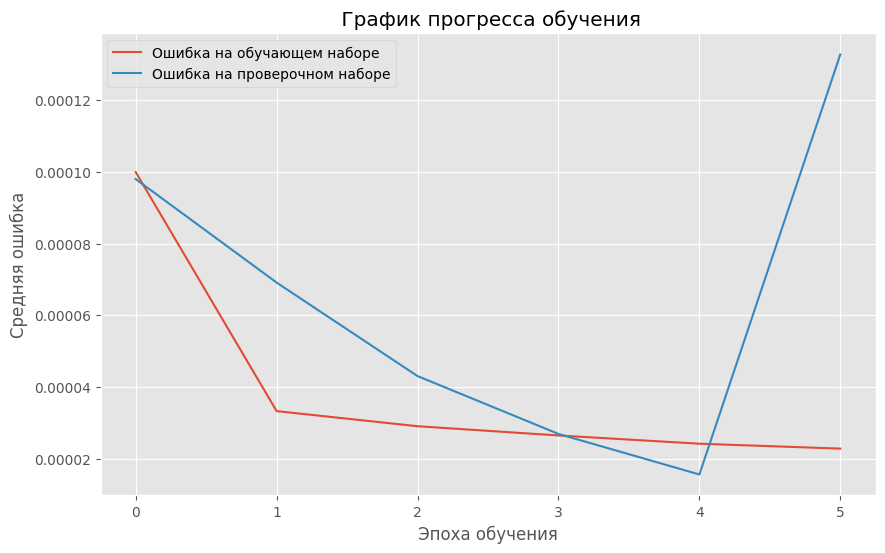

In [17]:
# Рисование графиков прошедшей фазы обучения
fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6), sharex=True)
ax1.set_title(f' График прогресса обучения')
ax1.plot(history.history['loss'], label='Ошибка на обучающем наборе')
ax1.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
ax1.set_ylabel('Средняя ошибка')
ax1.legend()

# Указание показывать только целые метки шкалы оси x
fig.gca().xaxis.get_major_locator().set_params(integer=True)
plt.xlabel('Эпоха обучения')
plt.show()

In [18]:
def get_pred(model, # модель
             x_test, y_test, # тестовая выборка
             y_scaler): # масштабирующий объект для y

    # Вычисление и деномализация предсказания
    y_pred_unscaled = y_scaler.inverse_transform(model.predict(x_test))

    # Денормализация верных ответов
    y_test_unscaled = y_scaler.inverse_transform(y_test)

    # Возврат результата предсказания и верные ответы в исходном масштабе
    return y_pred_unscaled, y_test_unscaled

def show_predict2(y_pred, y_true, # прогноз данных и исходный ряд
                 start, # точка ряда, с которой начинается отрисовка графика
                 length, # количество точек для отрисовки графика
                 chn_list=[0], # список каналов данных для отрисовки (по умолчанию все)
                 chn_names=CHANNEL_Y, # список имен каналов данных
                 title=''):

    # Если список каналов пуст - отображаются все каналы
    if not chn_list:
        chn_list = list(range(y_true.shape[1]))

    # Построение графика по всем каналам данных
    plt.figure(figsize=(22, 6))
    #print(chn_list)
    for chn in chn_list:
        #print(chn, y_pred.shape, y_pred[:5])
        plt.plot(y_pred[start:start + length, chn],
                label=f'{chn_names[chn]} Прогноз')
        plt.plot(y_true[start:start + length, chn],
                label=f'{chn_names[chn]} Базовый')

    plt.title(title)
    plt.xlabel('Время')
    plt.ylabel('Данные')
    plt.legend()
    plt.show()

In [19]:
# Получение денормализованного предсказания и данных базового ряда
y_pred, y_true = get_pred(model, x_test, y_test, y_scaler)

919/919 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


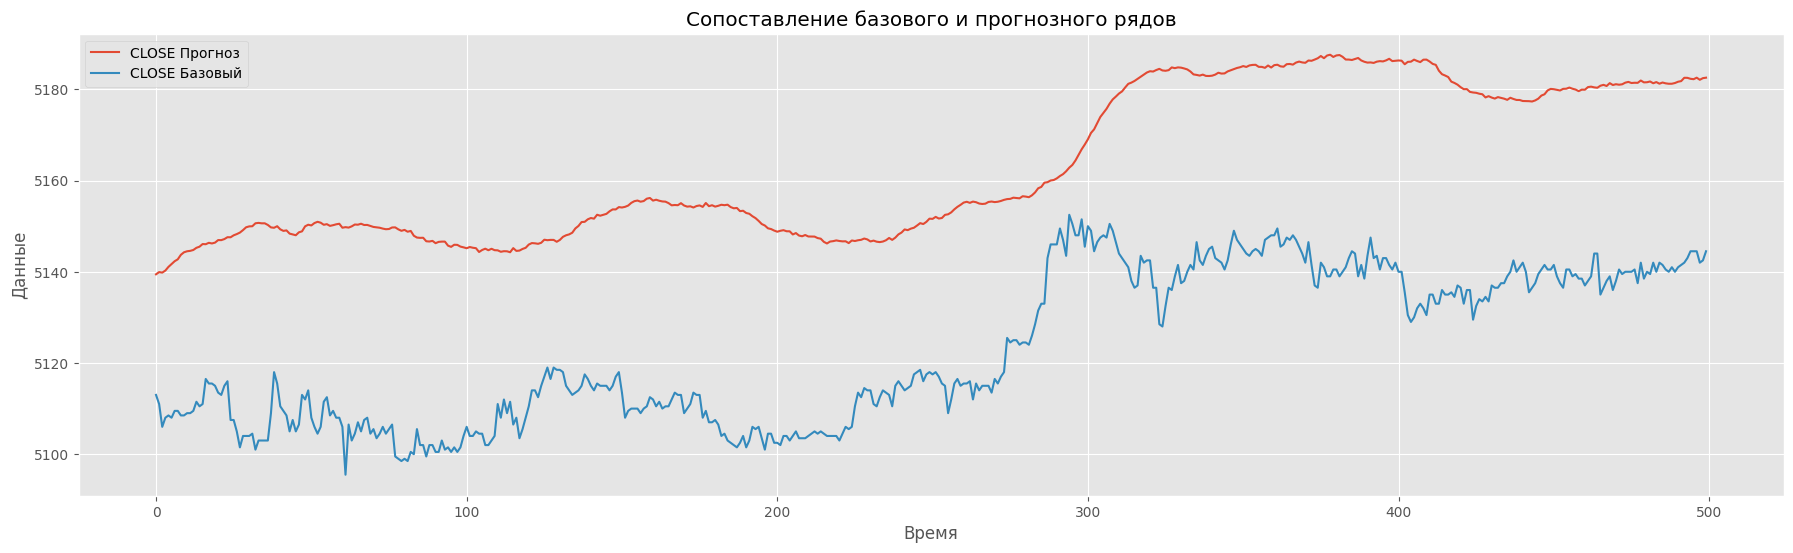

In [20]:
show_predict2(y_pred[1:], y_true[:-1], 0, 500,
              title=f'Сопоставление базового и прогнозного рядов')
